# Interactive Training and Learning

This notebook demonstrates the acetate learning workflow interactively.
It can retrain the LGP surrogates, rerun posterior sampling, export
validation-ready parameter samples, and generate a couple of posterior
plots.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from bff.bayes.results import InferenceResults
from bff.io.logs import Logger
from bff.plotting import plot_corner, plot_marginals
from bff.workflows.learn import build_problem
from bff.workflows.train import main as train_workflow

ROOT = Path('.').resolve()
TRAIN_CONFIG = ROOT.parent / '05-train-lgp' / 'config.yaml'
SPECS = ROOT.parent / '03-training-trjs' / 'trainset' / 'specs.yaml'
MODEL_PATHS = {
    'rdf': ROOT.parent / '05-train-lgp' / 'models' / 'rdf.lgp',
    'hb': ROOT.parent / '05-train-lgp' / 'models' / 'hb.lgp',
    'dist': ROOT.parent / '05-train-lgp' / 'models' / 'dist.lgp',
}
MCMC_OPTIONS = {
    'priors_disttype': 'normal',
    'total_steps': 10000,
    'warmup': 2000,
    'progress_stride': 1000,
    'fn_checkpoint': ROOT / 'mcmc-checkpoint.pt',
    'fn_posterior': ROOT / 'posterior.pt',
    'fn_priors': ROOT / 'priors.pt',
    'restart': False,
    'device': 'cuda',
    'rhat_tol': 1.05,
}

ROOT, TRAIN_CONFIG, SPECS, MODEL_PATHS

(PosixPath('/home/vojta/code/BayesicForceFields/examples/acetate/06-learn'),
 PosixPath('/home/vojta/code/BayesicForceFields/examples/acetate/05-train-lgp/config.yaml'),
 PosixPath('/home/vojta/code/BayesicForceFields/examples/acetate/03-training-trjs/trainset/specs.yaml'),
 {'rdf': PosixPath('/home/vojta/code/BayesicForceFields/examples/acetate/05-train-lgp/models/rdf.lgp'),
  'hb': PosixPath('/home/vojta/code/BayesicForceFields/examples/acetate/05-train-lgp/models/hb.lgp'),
  'dist': PosixPath('/home/vojta/code/BayesicForceFields/examples/acetate/05-train-lgp/models/dist.lgp')})

## 1. Retrain the surrogate models

Re-run this cell if you changed any dataset or training settings.

In [2]:
train_workflow(TRAIN_CONFIG)

## 2. Build and run posterior inference

This mirrors `bff.workflows.learn.main()` directly: the notebook
builds the `InferenceProblem` from `specs.yaml` and the selected
`.lgp` files without loading a learn config file.

In [5]:
logger = Logger('BFF-notebook', mode='w')
problem = build_problem(
    specs=SPECS,
    model_paths=MODEL_PATHS,
)
results = problem.infer(
    logger=logger,
    **MCMC_OPTIONS,
)

=== Posterior Inference ===                                                                         
                                                                                                    


  - Checkpoint: /home/vojta/code/BayesicForceFields/examples/acetate/06-learn/mcmc-checkpoint.pt        
> Posterior sampling: it.  3000/10000 | sampling: 1000/8000 | R-hat max: 1.0410/1.0500 | ESS min: 663/100 | acc: 0.275 | 280 it/s
                                                                                                    
> Posterior sampling: Done.                                                                           


## 3. Load, prepare, and export posterior samples

The exported `posterior-samples.yaml` can be used directly by the
`08-validate` stage.

In [6]:
results = InferenceResults.load(
    posterior=ROOT / 'posterior.pt',
    priors=ROOT / 'priors.pt',
    specs=SPECS,
)
results.prepare_samples()
results.sample_parameters(
    n_samples=10,
    fn_out=ROOT / 'posterior-samples.yaml',
    overwrite=True,
)
results.map_estimates

{'charge C1': -0.338,
 'charge H1 H2 H3': 0.049,
 'charge O1 O2': -0.615,
 '$\\sigma_{\\mathrm{rdf}}$': 1.82,
 '$\\sigma_{\\mathrm{hb}}$': 0.158,
 '$\\sigma_{\\mathrm{dist}}$': 0.143}

## 4. Plot the posterior

The figures are saved next to the notebook and displayed inline.

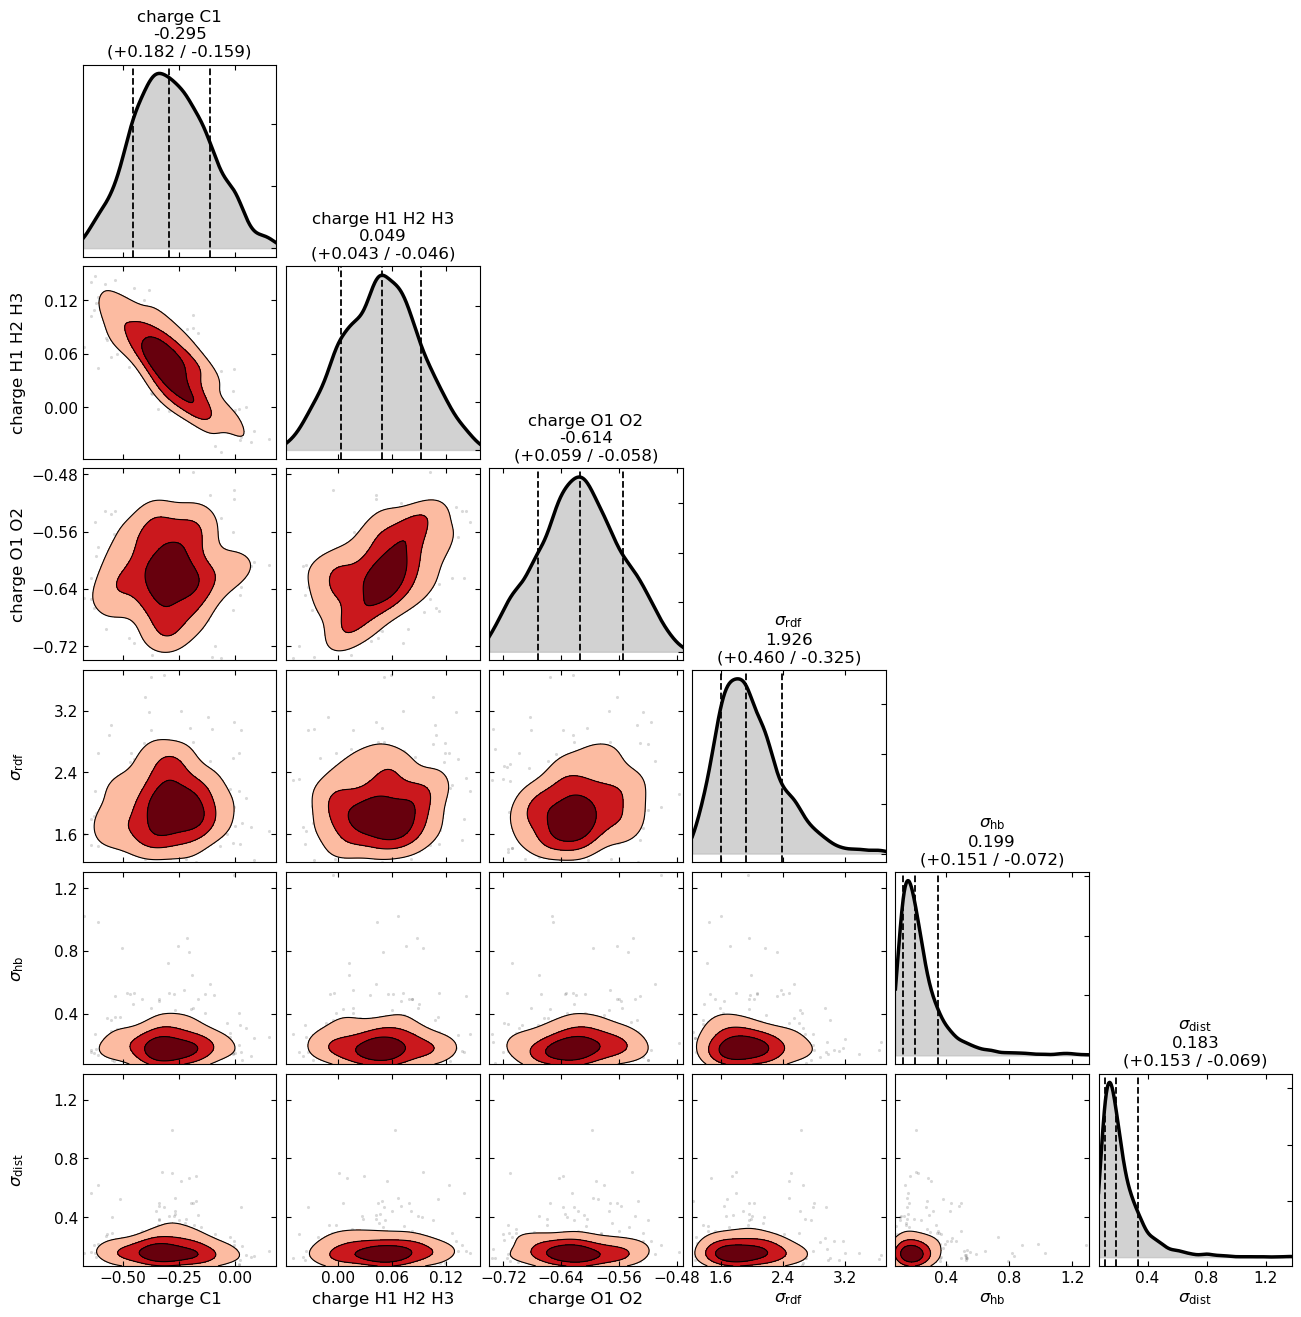

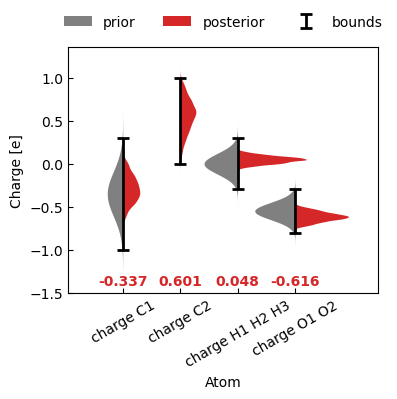

In [ ]:
plot_corner(results)
plot_marginals(results, SPECS)